# Robustness annex - cross-dataset summary

Aggregates the four per-dataset annex notebooks (`annex_sinus`, `annex_corners`,
`annex_spiral`, `annex_circles`) into one view, at the **full grid identical to
Case Study 2** (2 noise levels x 8 models x 7 ratios x 12 seeds = 1 344
runs/dataset). The 12-seed budget is what lets the pairwise Friedman + Wilcoxon
+ Holm protocol certify model pairs, so the headline of this notebook is the
**cross-dataset quantum-advantage table** (section 5): on how many datasets does
any quantum model beat a classical baseline with Holm-corrected significance?

Reads only `results/annex_<dataset>.json` (produced by `python run_annex.py`).

## 1. Imports

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
import qml_imbalance as qi
import run_annex as ra

os.makedirs('figures', exist_ok=True)
CONFIG = ra.CONFIG
ALL_MODELS = ra.ALL_MODELS
DATASETS = list(ra.td.DATASETS)
NOISES = CONFIG['noise_levels']
print('datasets:', DATASETS, '| noise levels:', NOISES)

datasets: ['sinus', 'corners', 'spiral', 'circles'] | noise levels: [0.1, 0.3]


## 2. Load all caches

`res[dataset][noise]` is a list of `qi.RunResult`, identical in structure to the
main study's `results_by_noise`.

In [2]:
res, missing = {}, []
for ds in DATASETS:
    try:
        res[ds] = ra.records_to_results_by_noise(ra.load_records(ds))
    except FileNotFoundError:
        missing.append(ds)
if missing:
    print('MISSING caches (run `python run_annex.py`):', missing)
for ds in res:
    print(f'{ds:8s}: ' + ', '.join(f'noise={n}:{len(res[ds][n])}' for n in NOISES))

sinus   : noise=0.1:672, noise=0.3:672
corners : noise=0.1:672, noise=0.3:672
spiral  : noise=0.1:672, noise=0.3:672
circles : noise=0.1:672, noise=0.3:672


## 3. The four datasets

Balanced base pool of each dataset (noise = 0.1), reproducing Fig. 12 of the
paper.

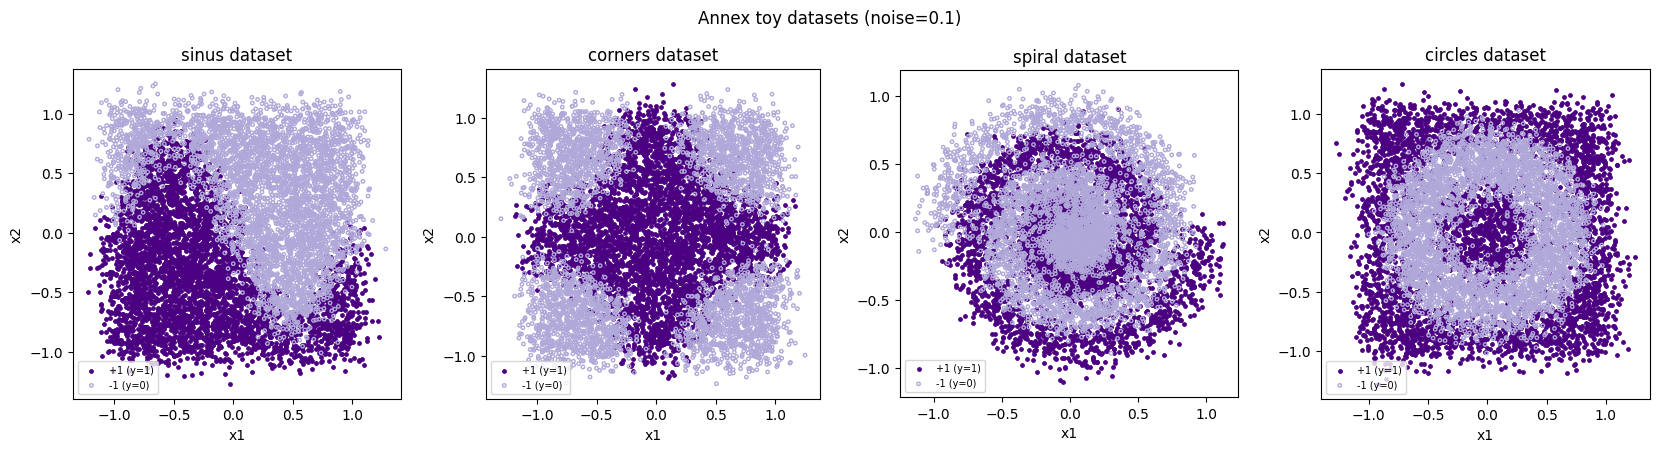

In [3]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.2 * len(DATASETS), 4.2))
for ax, ds in zip(axes, DATASETS):
    X, y = ra.make_base(ds, 0.1)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=6, c='indigo', label='+1 (y=1)')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=6, facecolors='none',
               edgecolors='#b0a8d8', label='-1 (y=0)')
    ax.set_title(f'{ds} dataset'); ax.set_aspect('equal', 'box')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(loc='lower left', fontsize=7)
plt.suptitle('Annex toy datasets (noise=0.1)', y=1.02)
plt.tight_layout()
plt.savefig('figures/summary-datasets.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Degradation curves, all datasets (one row per noise level)

Solid = quantum, dashed = classical; bands are +-1 std across the 12 seeds. This
is the headline cross-dataset figure: compare the relative ordering of the
curves with the main study.

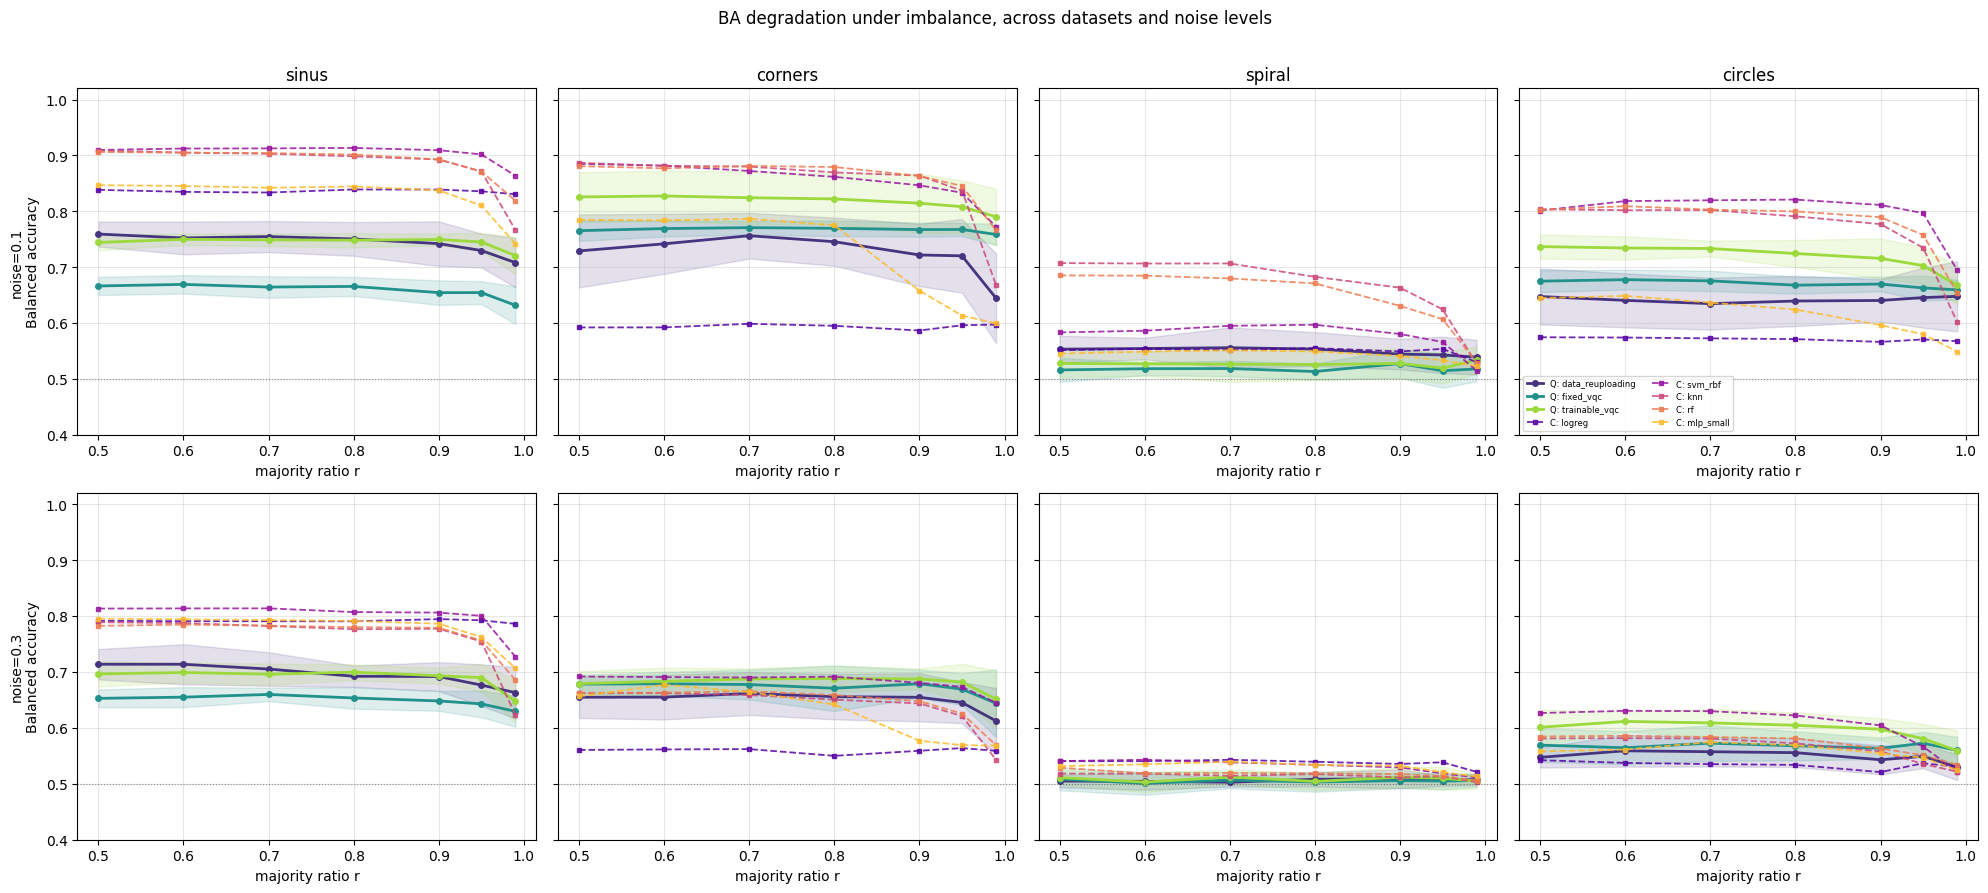

In [4]:
def collect(rlist, m, metric='balanced_accuracy'):
    agg = qi.aggregate(rlist, by=('model', 'ratio'),
                       metric=('roc_auc' if metric == 'roc_auc' else 'balanced_accuracy'))
    rs = sorted(CONFIG['ratios']); mu, sd = [], []
    for r in rs:
        row = next((x for x in agg if x['model'] == m and x['ratio'] == r), None)
        mu.append(row['balanced_accuracy_mean'] if row else np.nan)
        sd.append(row['balanced_accuracy_std'] if row else 0.0)
    return np.array(rs), np.array(mu), np.array(sd)

cmap_q = plt.cm.viridis(np.linspace(0.15, 0.85, len(CONFIG['quantum_models'])))
cmap_c = plt.cm.plasma(np.linspace(0.15, 0.85, len(CONFIG['classical_models'])))
fig, axes = plt.subplots(len(NOISES), len(res),
                         figsize=(5.0 * len(res), 4.4 * len(NOISES)),
                         sharey=True, squeeze=False)
for i, noise in enumerate(NOISES):
    for j, ds in enumerate(res):
        ax = axes[i, j]
        for m, c in zip(CONFIG['quantum_models'], cmap_q):
            rs, mu, sd = collect(res[ds][noise], m)
            ax.plot(rs, mu, '-o', color=c, lw=2, ms=4, label=f'Q: {m}')
            ax.fill_between(rs, mu - sd, mu + sd, color=c, alpha=0.15)
        for m, c in zip(CONFIG['classical_models'], cmap_c):
            rs, mu, sd = collect(res[ds][noise], m)
            ax.plot(rs, mu, '--s', color=c, lw=1.3, ms=3, alpha=0.85, label=f'C: {m}')
        ax.axhline(0.5, color='k', ls=':', lw=0.8, alpha=0.4)
        ax.set_ylim([0.4, 1.02]); ax.grid(True, alpha=0.3)
        if i == 0: ax.set_title(ds)
        if j == 0: ax.set_ylabel(f'noise={noise}\nBalanced accuracy')
        ax.set_xlabel('majority ratio r')
axes[0, -1].legend(loc='lower left', fontsize=6, ncol=2)
plt.suptitle('BA degradation under imbalance, across datasets and noise levels', y=1.01)
plt.tight_layout()
plt.savefig('figures/summary-degradation.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Cross-dataset quantum-advantage table (the headline)

Mirrors section 9 of the main study, per dataset and noise level: for each
(quantum, classical) pair, count the ratios (out of 7) at which the paired
Friedman + Wilcoxon + Holm protocol rejects H0 at alpha=0.05 **in favour of the
quantum model** (positive mean BA difference). A nonzero count means certified
quantum advantage on that dataset at that noise level. This is only meaningful
because the grid runs 12 seeds.

In [5]:
def q_beats_c(stats_per_ratio, qm, cm, r, alpha=0.05):
    st = stats_per_ratio[r]
    if np.isnan(st['friedman_p']) or st['friedman_p'] >= alpha:
        return False
    pair = st['pairwise']
    key = (qm, cm) if (qm, cm) in pair else (cm, qm)
    if key not in pair:
        return False
    info = pair[key]
    # mean_diff is (first - second); advantage for qm means qm scored higher
    diff = info['mean_diff'] if key == (qm, cm) else -info['mean_diff']
    return info['reject_holm'] and diff > 0

print(f'Certified quantum-advantage count (ratios out of 7, Holm p<0.05, q>c)')
for noise in NOISES:
    print(f'\n=== noise = {noise} ===')
    print(f'{"q \\ c":<18}' + ''.join(c.rjust(10) for c in CONFIG['classical_models']))
    for ds in res:
        spr = qi.friedman_wilcoxon_holm(res[ds][noise], alpha=0.05)
        print(f'-- {ds} --')
        for qm in CONFIG['quantum_models']:
            line = f'{qm:<18}'
            for cm in CONFIG['classical_models']:
                n = sum(q_beats_c(spr, qm, cm, r) for r in CONFIG['ratios'])
                line += (f'{n}' if n else '.').rjust(10)
            print(line)

Certified quantum-advantage count (ratios out of 7, Holm p<0.05, q>c)

=== noise = 0.1 ===
q \ c                 logreg   svm_rbf       knn        rf mlp_small


-- sinus --
data_reuploading           .         .         .         .         .
fixed_vqc                  .         .         .         .         .
trainable_vqc              .         .         .         .         .


-- corners --
data_reuploading           6         .         .         .         1
fixed_vqc                  7         .         1         .         2
trainable_vqc              7         .         1         .         3


-- spiral --
data_reuploading           .         .         .         .         .
fixed_vqc                  .         .         .         .         .
trainable_vqc              .         .         .         .         .


-- circles --
data_reuploading           7         .         .         .         2
fixed_vqc                  7         .         1         .         3
trainable_vqc              7         .         1         .         7

=== noise = 0.3 ===
q \ c                 logreg   svm_rbf       knn        rf mlp_small


-- sinus --
data_reuploading           .         .         .         .         .
fixed_vqc                  .         .         .         .         .
trainable_vqc              .         .         .         .         .


-- corners --
data_reuploading           6         .         1         .         2
fixed_vqc                  6         .         2         2         2
trainable_vqc              7         .         4         3         3


-- spiral --
data_reuploading           .         .         .         .         .
fixed_vqc                  .         .         .         .         .
trainable_vqc              .         .         .         .         .


-- circles --
data_reuploading           .         .         .         .         .
fixed_vqc                  4         .         2         .         .
trainable_vqc              6         .         4         1         2


## 6. Head-to-head at r = 0.99, all datasets (noise = 0.1)

Quantum (blue) vs classical (orange) at the most extreme imbalance.

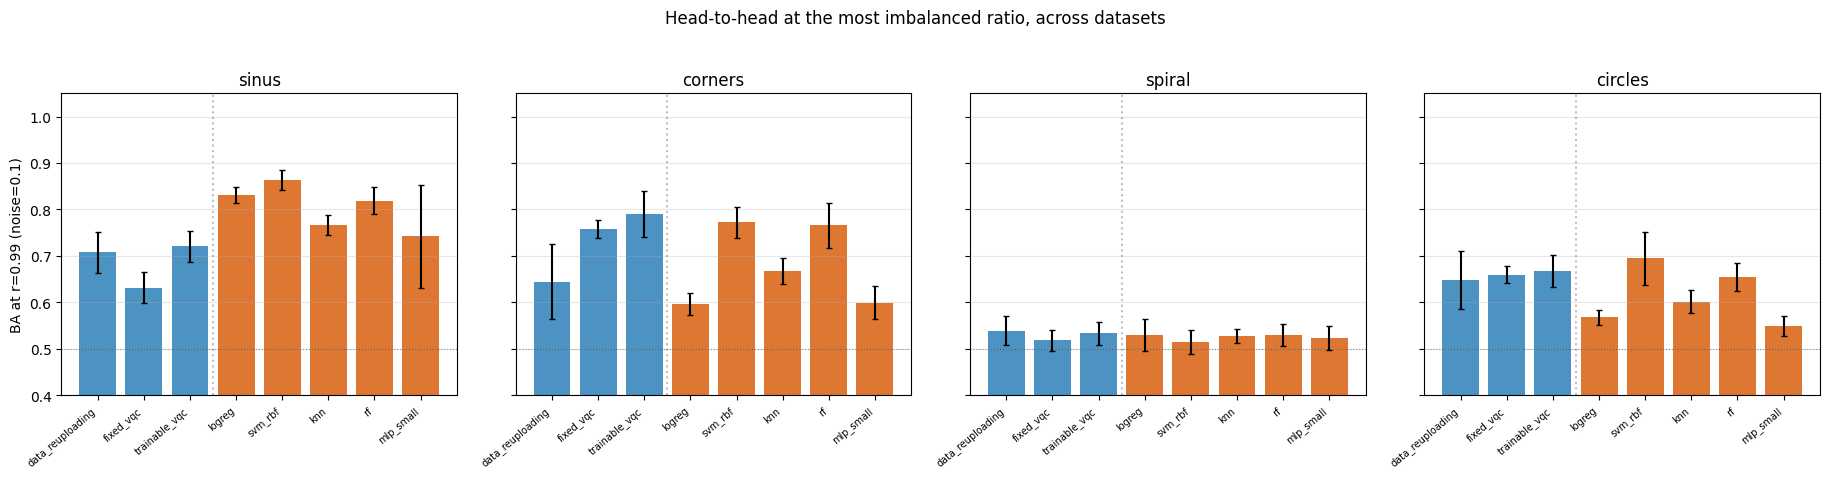

In [6]:
extreme = max(CONFIG['ratios']); noise = 0.1
n_q = len(CONFIG['quantum_models'])
colors = ['#2c7fb8'] * n_q + ['#d95f0e'] * (len(ALL_MODELS) - n_q)
fig, axes = plt.subplots(1, len(res), figsize=(4.6 * len(res), 4.6),
                         sharey=True, squeeze=False)
for ax, ds in zip(axes[0], res):
    agg = qi.aggregate(res[ds][noise], by=('model', 'ratio'))
    means, stds = [], []
    for m in ALL_MODELS:
        row = next((r for r in agg if r['model'] == m and r['ratio'] == extreme), None)
        means.append(row['balanced_accuracy_mean'] if row else np.nan)
        stds.append(row['balanced_accuracy_std'] if row else 0.0)
    xs = np.arange(len(ALL_MODELS))
    ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85, capsize=2)
    ax.axhline(0.5, color='k', ls=':', lw=0.8, alpha=0.4)
    ax.axvline(n_q - 0.5, color='gray', ls=':', alpha=0.5)
    ax.set_xticks(xs); ax.set_xticklabels(ALL_MODELS, rotation=40, ha='right', fontsize=7)
    ax.set_title(ds); ax.set_ylim([0.4, 1.05]); ax.grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylabel(f'BA at r={extreme:.2f} (noise={noise})')
plt.suptitle('Head-to-head at the most imbalanced ratio, across datasets', y=1.03)
plt.tight_layout()
plt.savefig('figures/summary-headtohead.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Robustness-slope table (noise = 0.1)

`slope = mean BA(r=0.5) - mean BA(r=0.99)` per (dataset, model); smaller = more
robust to imbalance.

In [7]:
noise = 0.1
def slope(rlist, m):
    a = np.array([x.metrics['balanced_accuracy'] for x in rlist
                  if x.model == m and x.ratio == 0.5])
    b = np.array([x.metrics['balanced_accuracy'] for x in rlist
                  if x.model == m and x.ratio == 0.99])
    return float(a.mean() - b.mean()) if len(a) and len(b) else np.nan

header = f'{"model":<18s}' + ''.join(ds.rjust(10) for ds in res)
print(header); print('-' * len(header))
for m in ALL_MODELS:
    line = f'{m:<18s}'
    for ds in res:
        s = slope(res[ds][noise], m)
        line += (f'{s:+.3f}'.rjust(10) if not np.isnan(s) else 'n/a'.rjust(10))
    print(line)

model                  sinus   corners    spiral   circles
----------------------------------------------------------
data_reuploading      +0.051    +0.085    +0.014    -0.000
fixed_vqc             +0.035    +0.007    -0.002    +0.015
trainable_vqc         +0.024    +0.035    -0.006    +0.069
logreg                +0.008    -0.005    +0.021    +0.007
svm_rbf               +0.046    +0.112    +0.068    +0.106
knn                   +0.142    +0.218    +0.180    +0.202
rf                    +0.087    +0.115    +0.156    +0.149
mlp_small             +0.105    +0.185    +0.022    +0.096


## 8. Verdict

Read the annex conclusion off the cross-dataset table (sec. 5) and curves
(sec. 4):

* On `make_moons` (main study), the strong classical baselines (SVM-RBF, RF)
  lead at extreme imbalance and **no quantum model achieves Holm-certified
  advantage**; the verdict is "no quantum advantage in this regime".
* If the four toy datasets keep that picture -- quantum-advantage counts at or
  near zero, classical baselines leading the degradation curves -- the annex
  concludes the make_moons verdict **transfers** and is not an artefact of the
  two-moons geometry. Any dataset where a quantum model *does* earn a certified
  win is worth calling out explicitly.

(Now that the grid is identical to the main study at 12 seeds, the pairwise
protocol is fully in force, so these statements are certified, not descriptive.)
